# **From Data to Decisions: Leveraging PySpark and ML to Predict Loan Defaults**



# **Executive Summary**

### The primary objective of this project is to address the issue of loan defaults, which detrimentally impact both financial institutions and the broader economy. For instance, imagine a scenario where two individuals have applied for a loan. Person A boasts an excellent credit history and seeks the loan to complete the construction of their home. Conversely, Person B possesses a decent credit history but demonstrates a lack of seriousness towards repayment, potentially having delinquencies. Various factors such as home ownership, monthly income, and total remaining balance contribute to the assessment. In the event of loan repayment failure, it is classified as a default loan, resulting in losses for the financial institution or bank. Consequently, to mitigate these losses, they may increase overall interest rates, impacting even those who have maintained good repayment practices. When extrapolated to a larger scale involving hundreds of thousands of individuals, a notable ratio may default on their loans. This scenario not only affects the individuals involved but also has wider ramifications for the economy as a whole. Therefore, by preemptively identifying potential loan defaulters, the banking and financial sectors can minimize losses and make informed lending decisions.

### The Dataset is obtained from Machine Hack Data Repository. This is a Binary Classification Problem. The dataset has information related to Loan Applications. It has 96376 samples and 35 features. Intially Exploratory data analysis was performed and the data was cleaned using PySpark. Analyzed the schema of the Dataset and removed the redundant features. Standardized categorical labels to reconcile variations referring to the same entity. Conducted multiple group-by and aggregation operations to derive statistical insights from the dataset. Next, Data visualuzation section was created, various plots were displayed in order to understand the dynamics of the problem and also visualize the relationship between various features. As the Target feature was highly imbalanced we applied SMOTE in order to balance the minority class. Then we performed label encoding and scaled down the entire dataset, so that the model would provide equal importance to all features.

### Next, we split the data into train and validation sets, then we trained 5 Machine Learning models on the training data using Hold Out method and then classified the output on the test data. By observing and comparing the results of these process, finally XGBoost model was concluded as the best performing model with accuarcy of 88 percentage.

# **Installations**

In [1]:
!pip install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.5.1-py2.py3-none-any.whl size=317488491 sha256=3aaa8eec4ef28fac65fb235ddc0f61aa57cf7eec5a93d3ecd45b6e8655fea3b1
  Stored in directory: /root/.cache/pip/wheels/80/1d/60/2c256ed38dddce2fdd93be545214a63e02fbd8d74fb0b7f3a6
Successfully built pyspark


In [2]:
!pip install findspark

# **Imports**

In [3]:
import os
import sys
import findspark
from pyspark.sql import SparkSession
from pyspark.sql.functions import row_number, monotonically_increasing_id
from pyspark.sql import Window
from pyspark.sql.functions import desc
from pyspark.sql.functions import when
from pyspark.sql.functions import col as spark_col
from pyspark.sql.functions import ceil
from pyspark.sql.functions import col
from pyspark.sql.functions import lit
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score, classification_report, confusion_matrix, f1_score

#**Data Cleaning and Exploratory Data Analysis with PySpark**

In [ ]:
os.environ['PYSPARK_PYTHON'] = sys.executable

os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

findspark.init()

In [ ]:
# Initializing the sparksesstion.

spark = SparkSession \
    .builder \
    .appName("Python Spark SQL basic example") \
    .config("spark.some.config.option", "some-value") \
    .getOrCreate()

## Load the Dataset

In [ ]:
loan_df = spark.read.csv("/content/sample_data/Loan_Default.csv", header=True, inferSchema=True)

In [ ]:
# To count the total rows in the dataframe.
print('Number of rows: \t', loan_df.count())

# Number of columns can be counted in this way
print('Number of columns: \t', len(loan_df.columns))

Number of rows: 	 96376
Number of columns: 	 35


In [ ]:
loan_df.show(5)

+--------+-----------+-------------+----------------------+----+--------------+-------------+-----+---------+-------------------+--------------+-------------------+------------+--------------------+---------------+-----------------------+---------------------+------------+-------------+-----------------+-------------------+--------------+-------------------+-----------------------+-----------------------+-----------+-----------------------+----------------------------+----------------+-------------+-------------------+-----------------------+---------------------+----------------------------+-----------+
|      ID|Loan Amount|Funded Amount|Funded Amount Investor|Term|Batch Enrolled|Interest Rate|Grade|Sub Grade|Employment Duration|Home Ownership|Verification Status|Payment Plan|          Loan Title|Debit to Income|Delinquency - two years|Inquires - six months|Open Account|Public Record|Revolving Balance|Revolving Utilities|Total Accounts|Initial List Status|Total Received Interest|Tota

In [ ]:
loan_df = loan_df.withColumn("index",monotonically_increasing_id())

loan_df.show(5)

+--------+-----------+-------------+----------------------+----+--------------+-------------+-----+---------+-------------------+--------------+-------------------+------------+--------------------+---------------+-----------------------+---------------------+------------+-------------+-----------------+-------------------+--------------+-------------------+-----------------------+-----------------------+-----------+-----------------------+----------------------------+----------------+-------------+-------------------+-----------------------+---------------------+----------------------------+-----------+-----+
|      ID|Loan Amount|Funded Amount|Funded Amount Investor|Term|Batch Enrolled|Interest Rate|Grade|Sub Grade|Employment Duration|Home Ownership|Verification Status|Payment Plan|          Loan Title|Debit to Income|Delinquency - two years|Inquires - six months|Open Account|Public Record|Revolving Balance|Revolving Utilities|Total Accounts|Initial List Status|Total Received Interes

In [ ]:
# To view the names of the columns.

print('\nName of columns: \n', loan_df.columns)


Name of columns: 
 ['ID', 'Loan Amount', 'Funded Amount', 'Funded Amount Investor', 'Term', 'Batch Enrolled', 'Interest Rate', 'Grade', 'Sub Grade', 'Employment Duration', 'Home Ownership', 'Verification Status', 'Payment Plan', 'Loan Title', 'Debit to Income', 'Delinquency - two years', 'Inquires - six months', 'Open Account', 'Public Record', 'Revolving Balance', 'Revolving Utilities', 'Total Accounts', 'Initial List Status', 'Total Received Interest', 'Total Received Late Fee', 'Recoveries', 'Collection Recovery Fee', 'Collection 12 months Medical', 'Application Type', 'Last week Pay', 'Accounts Delinquent', 'Total Collection Amount', 'Total Current Balance', 'Total Revolving Credit Limit', 'Loan Status', 'index']


In [ ]:
# Here we reorder columns using select.

loan_df = loan_df.select('index', 'ID', 'Loan Amount', 'Funded Amount', 'Funded Amount Investor', 'Term', 'Batch Enrolled', 'Interest Rate', 'Grade', 'Sub Grade', 'Employment Duration', 'Home Ownership', 'Verification Status', 'Payment Plan', 'Loan Title', 'Debit to Income', 'Delinquency - two years', 'Inquires - six months', 'Open Account', 'Public Record', 'Revolving Balance', 'Revolving Utilities', 'Total Accounts', 'Initial List Status', 'Total Received Interest', 'Total Received Late Fee', 'Recoveries', 'Collection Recovery Fee', 'Collection 12 months Medical', 'Application Type', 'Last week Pay', 'Accounts Delinquent', 'Total Collection Amount', 'Total Current Balance', 'Total Revolving Credit Limit', 'Loan Status')

loan_df.show(5)

+-----+--------+-----------+-------------+----------------------+----+--------------+-------------+-----+---------+-------------------+--------------+-------------------+------------+--------------------+---------------+-----------------------+---------------------+------------+-------------+-----------------+-------------------+--------------+-------------------+-----------------------+-----------------------+-----------+-----------------------+----------------------------+----------------+-------------+-------------------+-----------------------+---------------------+----------------------------+-----------+
|index|      ID|Loan Amount|Funded Amount|Funded Amount Investor|Term|Batch Enrolled|Interest Rate|Grade|Sub Grade|Employment Duration|Home Ownership|Verification Status|Payment Plan|          Loan Title|Debit to Income|Delinquency - two years|Inquires - six months|Open Account|Public Record|Revolving Balance|Revolving Utilities|Total Accounts|Initial List Status|Total Received I

### There was a mismatch of Fearture names, the headers were inter-changed ( Home Ownership & Employment Duration ), therefore the following code replaces them accordingly.

In [ ]:
# Interchange column names
loan_df = loan_df.withColumnRenamed("Employment Duration", "temp_column") \
       .withColumnRenamed("Home Ownership", "Employment Duration") \
       .withColumnRenamed("temp_column", "Home Ownership")

# Show DataFrame with column names interchanged
loan_df.show(5)

+-----+--------+-----------+-------------+----------------------+----+--------------+-------------+-----+---------+--------------+-------------------+-------------------+------------+--------------------+---------------+-----------------------+---------------------+------------+-------------+-----------------+-------------------+--------------+-------------------+-----------------------+-----------------------+-----------+-----------------------+----------------------------+----------------+-------------+-------------------+-----------------------+---------------------+----------------------------+-----------+
|index|      ID|Loan Amount|Funded Amount|Funded Amount Investor|Term|Batch Enrolled|Interest Rate|Grade|Sub Grade|Home Ownership|Employment Duration|Verification Status|Payment Plan|          Loan Title|Debit to Income|Delinquency - two years|Inquires - six months|Open Account|Public Record|Revolving Balance|Revolving Utilities|Total Accounts|Initial List Status|Total Received I

In [ ]:
# View the schema of the dataset
loan_df.printSchema()

root
 |-- index: long (nullable = false)
 |-- ID: integer (nullable = true)
 |-- Loan Amount: integer (nullable = true)
 |-- Funded Amount: integer (nullable = true)
 |-- Funded Amount Investor: double (nullable = true)
 |-- Term: integer (nullable = true)
 |-- Batch Enrolled: string (nullable = true)
 |-- Interest Rate: double (nullable = true)
 |-- Grade: string (nullable = true)
 |-- Sub Grade: string (nullable = true)
 |-- Home Ownership: string (nullable = true)
 |-- Employment Duration: double (nullable = true)
 |-- Verification Status: string (nullable = true)
 |-- Payment Plan: string (nullable = true)
 |-- Loan Title: string (nullable = true)
 |-- Debit to Income: double (nullable = true)
 |-- Delinquency - two years: integer (nullable = true)
 |-- Inquires - six months: integer (nullable = true)
 |-- Open Account: integer (nullable = true)
 |-- Public Record: integer (nullable = true)
 |-- Revolving Balance: integer (nullable = true)
 |-- Revolving Utilities: double (nullable

In [ ]:
# Count the value of null in every column
for col in loan_df.columns:
    print(col, "\t", "with null values: ", loan_df.filter(loan_df[col].isNull()).count())

index 	 with null values:  0
ID 	 with null values:  0
Loan Amount 	 with null values:  0
Funded Amount 	 with null values:  0
Funded Amount Investor 	 with null values:  0
Term 	 with null values:  0
Batch Enrolled 	 with null values:  0
Interest Rate 	 with null values:  0
Grade 	 with null values:  0
Sub Grade 	 with null values:  0
Home Ownership 	 with null values:  0
Employment Duration 	 with null values:  0
Verification Status 	 with null values:  0
Payment Plan 	 with null values:  0
Loan Title 	 with null values:  0
Debit to Income 	 with null values:  0
Delinquency - two years 	 with null values:  0
Inquires - six months 	 with null values:  0
Open Account 	 with null values:  0
Public Record 	 with null values:  0
Revolving Balance 	 with null values:  0
Revolving Utilities 	 with null values:  0
Total Accounts 	 with null values:  0
Initial List Status 	 with null values:  0
Total Received Interest 	 with null values:  0
Total Received Late Fee 	 with null values:  0
Recov

### The following code shows the categories that are present in the '**Grade**' feature. We can observe that almost 85 percent of the people fall into Grades A, B, C and D.


### *   **Grade A** - Refers to people with Good income, Excellent credit score, Lower credit risk, Lower interest rates.
### *   **Grade B** - Refers to people who may have a Stable income and Decent credit scores but, slightly higher Credit risks and Debt levels, possibility of Shorter Credit History, hence higher Interest rates than Grade A.
### *   **Grade C** - Refers to people with moderate level of credit risk, moderate Credit scores and Income, shorter Credit History, this implies to higher Interest rates than Grade A and Grade B.
### *   **Grade D** - Refers to people with Higher level of credit risks, lower credit scores and Income. They have High Debt levels and History of Delinquencies. Hence higher Interest rates than Grades A, B and C.
### *   **Grade E, F & G** - These categories have the riskiest Loan Borrowers, very poor Credit scores, History of Bankruptcy, History of Delinquencies and Defaults. Therfore they have the highest Interest rates when compared with other Grades.








In [ ]:
loan_df.groupBy('Grade').count().show()

+-----+-----+
|Grade|count|
+-----+-----+
|    F| 3128|
|    E| 9054|
|    B|26738|
|    D|12211|
|    C|27189|
|    A|17174|
|    G|  882|
+-----+-----+



### The feature '**Initial List Status**' has 2 uniques categories, we can see that they are evenly distributed, it's significance is explanined below.


### *   **w** - It refers to '**Whole**' Loan, In Peer-to-Peer funding or Crowdfunding platforms there are scenarios wherein a Single Investor funds the entire Loan.
### *   **f** - It refers to '**Fractional**' Loan, this signifies the instances where multiple Investors contribute to fund a portion of the Loan.



In [ ]:
loan_df.groupBy('Initial List Status').count().show()

+-------------------+-----+
|Initial List Status|count|
+-------------------+-----+
|                  f|44229|
|                  w|52147|
+-------------------+-----+



### The following section refers to categories that are present in '**Home Ownership**' feature.

### * Here we can observe that 90 percent of the distribution consists of people who are paying Mortgages and Rents. This also makes complete sense for them to have taken various Loans.

In [ ]:
loan_df.groupBy('Home Ownership').count().show()

+--------------+-----+
|Home Ownership|count|
+--------------+-----+
|           OWN| 9812|
|          RENT|34683|
|      MORTGAGE|51881|
+--------------+-----+



### Now let's analyze the '**Payment Plan**' Feature. Throught the dataset it just has the character 'n' as its data, so ideally it does not provide any kind of significant information. Therefore let's delete the feature from the dataset.

In [ ]:
loan_df.groupBy('Payment Plan').count().show()

+------------+-----+
|Payment Plan|count|
+------------+-----+
|           n|96376|
+------------+-----+



In [ ]:
loan_df = loan_df.drop('Payment Plan')

### * Here we can observe the top 20 categories that are present in '**Loan Title**' feature.
###* We can observe that there are multiple data points that are similar to each other. Hence let's group them into one, this would streamline the process and would also benefit the analysis.

In [ ]:
loan_df.groupBy('Loan Title').count().orderBy(desc("count")).show(truncate=False)

+-------------------------+-----+
|Loan Title               |count|
+-------------------------+-----+
|Credit card refinancing  |42084|
|Debt consolidation       |37100|
|Debt Consolidation       |4688 |
|Other                    |3561 |
|Home improvement         |3293 |
|Major purchase           |746  |
|Medical expenses         |379  |
|Business                 |300  |
|Moving and relocation    |253  |
|Car financing            |230  |
|Vacation                 |190  |
|debt consolidation       |174  |
|Consolidation            |171  |
|Home buying              |152  |
|Personal Loan            |115  |
|Debt Consolidation Loan  |110  |
|Credit Card Consolidation|106  |
|Home Improvement         |94   |
|Consolidate              |87   |
|consolidation            |78   |
+-------------------------+-----+
only showing top 20 rows



### There is 109 unique values in 'Loan Title' feature, there are multiple similarities and discrepancies, therefore it is necessary to handle them and reduce the count of unique features.

In [ ]:
# Display the number of distinct values in the 'Loan Title' column
unique_count = loan_df.select("Loan Title").distinct().count()
print("Number of unique values in 'Loan Title' column:", unique_count)

Number of unique values in 'Loan Title' column: 109


### Here we are handling 'Debt Consolidation' data label. We are converting all the similar data labels into one.

In [ ]:
# Replace 'Debt consolidation' with 'Debt Consolidation' and 'Credit card refinancing' with 'Credit Card Refinancing' in the 'Loan Title' column
loan_df = loan_df.withColumn('Loan Title',
                             when(loan_df['Loan Title'] == 'Debt consolidation', 'Debt Consolidation')
                             .when(loan_df['Loan Title'] == 'debt consolidation', 'Debt Consolidation')
                             .when(loan_df['Loan Title'] == 'Consolidation', 'Debt Consolidation')
                             .when(loan_df['Loan Title'] == 'consolidation', 'Debt Consolidation')
                             .when(loan_df['Loan Title'] == 'DEBT CONSOLIDATION', 'Debt Consolidation')
                             .when(loan_df['Loan Title'] == 'Debt Consolidation Loan', 'Debt Consolidation')
                             .when(loan_df['Loan Title'] == 'debt consolidation loan', 'Debt Consolidation')
                             .when(loan_df['Loan Title'] == 'consolidate', 'Debt Consolidation')
                             .when(loan_df['Loan Title'] == 'Consolidate', 'Debt Consolidation')
                             .when(loan_df['Loan Title'] == 'consolidation loan', 'Debt Consolidation')
                             .when(loan_df['Loan Title'] == 'Consolidation Loan', 'Debt Consolidation')
                             .when(loan_df['Loan Title'] == 'Debt', 'Debt Consolidation')
                             .when(loan_df['Loan Title'] == 'debt', 'Debt Consolidation')
                             .otherwise(loan_df['Loan Title']))

### Here we are handling 'Credit Card Refinancing' data label. We are converting all the similar data labels into one to enable easier data manipulation.

In [ ]:
# Replace 'Debt consolidation' with 'Debt Consolidation' and 'Credit card refinancing' with 'Credit Card Refinancing' in the 'Loan Title' column
loan_df = loan_df.withColumn('Loan Title',
                             when(loan_df['Loan Title'] == 'Credit Card Consolidation', 'Credit Card Refinancing')
                             .when(loan_df['Loan Title'] == 'Credit Card Debt', 'Credit Card Refinancing')
                             .when(loan_df['Loan Title'] == 'Credit card refinancing', 'Credit Card Refinancing')
                             .when(loan_df['Loan Title'] == 'Credit Card Refinance', 'Credit Card Refinancing')
                             .when(loan_df['Loan Title'] == 'Credit card refinance', 'Credit Card Refinancing')
                             .when(loan_df['Loan Title'] == 'Credit Card Payoff', 'Credit Card Refinancing')
                             .when(loan_df['Loan Title'] == 'Credit Card', 'Credit Card Refinancing')
                             .when(loan_df['Loan Title'] == 'credit card', 'Credit Card Refinancing')
                             .when(loan_df['Loan Title'] == 'Credit card payoff', 'Credit Card Refinancing')
                             .when(loan_df['Loan Title'] == 'Credit Cards', 'Credit Card Refinancing')
                             .when(loan_df['Loan Title'] == 'Credit Consolidation', 'Credit Card Refinancing')
                             .when(loan_df['Loan Title'] == 'Credit Card Loan', 'Credit Card Refinancing')
                             .otherwise(loan_df['Loan Title']))

In [ ]:
loan_df.groupBy('Loan Title').count().orderBy(desc("count")).show(truncate=False)

+-----------------------+-----+
|Loan Title             |count|
+-----------------------+-----+
|Debt Consolidation     |42766|
|Credit Card Refinancing|42677|
|Other                  |3561 |
|Home improvement       |3293 |
|Major purchase         |746  |
|Medical expenses       |379  |
|Business               |300  |
|Moving and relocation  |253  |
|Car financing          |230  |
|Vacation               |190  |
|Home buying            |152  |
|Personal Loan          |115  |
|Home Improvement       |94   |
|payoff                 |68   |
|Freedom                |64   |
|Green loan             |63   |
|personal               |48   |
|Loan                   |47   |
|Personal               |46   |
|Payoff                 |46   |
+-----------------------+-----+
only showing top 20 rows



### Now we can see that there as some more data values that can be merged.

In [ ]:
loan_df = loan_df.withColumn('Loan Title',
                             when(loan_df['Loan Title'] == 'Personal', 'Personal Loan')
                             .when(loan_df['Loan Title'] == 'personal', 'Personal Loan')
                             .when(loan_df['Loan Title'] == 'My Loan', 'Personal Loan')
                             .when(loan_df['Loan Title'] == 'refi', 'Refinance')
                             .when(loan_df['Loan Title'] == 'payoff', 'Payoff')
                             .when(loan_df['Loan Title'] == 'Home improvement', 'Home Improvement')
                             .otherwise(loan_df['Loan Title']))

In [ ]:
loan_df.groupBy('Loan Title').count().orderBy(desc("count")).show(truncate=False)

+-----------------------+-----+
|Loan Title             |count|
+-----------------------+-----+
|Debt Consolidation     |42766|
|Credit Card Refinancing|42677|
|Other                  |3561 |
|Home Improvement       |3387 |
|Major purchase         |746  |
|Medical expenses       |379  |
|Business               |300  |
|Moving and relocation  |253  |
|Personal Loan          |252  |
|Car financing          |230  |
|Vacation               |190  |
|Home buying            |152  |
|Payoff                 |114  |
|Refinance              |81   |
|Freedom                |64   |
|Green loan             |63   |
|Loan                   |47   |
|Lending Club           |40   |
|Loan 1                 |33   |
|Debt Free              |31   |
+-----------------------+-----+
only showing top 20 rows



### Here we can observe that, we have brought down the number of unique values from **109** to **79**.

In [ ]:
# Here we can view the number of distinct values in the 'Loan Title' column
unique_count = loan_df.select("Loan Title").distinct().count()
print("Number of unique values in 'Loan Title' column:", unique_count)

Number of unique values in 'Loan Title' column: 79


### Manipulating '**Verification Status**' feature

In [ ]:
loan_df.select('Verification Status').distinct().show()

# Here we replace 'Source Verified' with 'Verified' in the 'Verification Status' column
loan_df = loan_df.withColumn('Verification Status', when(loan_df['Verification Status'] == 'Source Verified', 'Verified').otherwise(loan_df['Verification Status']))
loan_df.select('Verification Status').distinct().show()


+-------------------+
|Verification Status|
+-------------------+
|           Verified|
|    Source Verified|
|       Not Verified|
+-------------------+

+-------------------+
|Verification Status|
+-------------------+
|           Verified|
|       Not Verified|
+-------------------+



### By anlyzing the 'Application Type' feature, we can conclude that majority of the Loan Applications are Individual Applications.

In [ ]:
loan_df.groupBy('Application Type').count().show()

+----------------+-----+
|Application Type|count|
+----------------+-----+
|           JOINT|  153|
|      INDIVIDUAL|96223|
+----------------+-----+



### Converting Interest Rate feature type from 'str' to 'float'. This would enable feature data manipulation.

In [ ]:
# Convert string column to float
loan_df = loan_df.withColumn("Interest_Rate", spark_col("Interest Rate").cast("float"))

# Show the updated DataFrame
loan_df.show(5)

+-----+--------+-----------+-------------+----------------------+----+--------------+-------------+-----+---------+--------------+-------------------+-------------------+--------------------+---------------+-----------------------+---------------------+------------+-------------+-----------------+-------------------+--------------+-------------------+-----------------------+-----------------------+-----------+-----------------------+----------------------------+----------------+-------------+-------------------+-----------------------+---------------------+----------------------------+-----------+-------------+
|index|      ID|Loan Amount|Funded Amount|Funded Amount Investor|Term|Batch Enrolled|Interest Rate|Grade|Sub Grade|Home Ownership|Employment Duration|Verification Status|          Loan Title|Debit to Income|Delinquency - two years|Inquires - six months|Open Account|Public Record|Revolving Balance|Revolving Utilities|Total Accounts|Initial List Status|Total Received Interest|Tota

In [ ]:
loan_df = loan_df.drop('Interest Rate')

In [ ]:
# To view the names of the columns
print('\nName of columns: \n', loan_df.columns)


Name of columns: 
 ['index', 'ID', 'Loan Amount', 'Funded Amount', 'Funded Amount Investor', 'Term', 'Batch Enrolled', 'Grade', 'Sub Grade', 'Home Ownership', 'Employment Duration', 'Verification Status', 'Loan Title', 'Debit to Income', 'Delinquency - two years', 'Inquires - six months', 'Open Account', 'Public Record', 'Revolving Balance', 'Revolving Utilities', 'Total Accounts', 'Initial List Status', 'Total Received Interest', 'Total Received Late Fee', 'Recoveries', 'Collection Recovery Fee', 'Collection 12 months Medical', 'Application Type', 'Last week Pay', 'Accounts Delinquent', 'Total Collection Amount', 'Total Current Balance', 'Total Revolving Credit Limit', 'Loan Status', 'Interest_Rate']


In [ ]:
# Now we reorder columns using select.
loan_df = loan_df.select('index', 'ID', 'Loan Amount', 'Funded Amount', 'Funded Amount Investor', 'Term', 'Batch Enrolled', 'Interest_Rate', 'Grade', 'Sub Grade', 'Home Ownership', 'Employment Duration', 'Verification Status', 'Loan Title', 'Debit to Income', 'Delinquency - two years', 'Inquires - six months', 'Open Account', 'Public Record', 'Revolving Balance', 'Revolving Utilities', 'Total Accounts', 'Initial List Status', 'Total Received Interest', 'Total Received Late Fee', 'Recoveries', 'Collection Recovery Fee', 'Collection 12 months Medical', 'Application Type', 'Last week Pay', 'Accounts Delinquent', 'Total Collection Amount', 'Total Current Balance', 'Total Revolving Credit Limit', 'Loan Status')

loan_df.show(5)

+-----+--------+-----------+-------------+----------------------+----+--------------+-------------+-----+---------+--------------+-------------------+-------------------+--------------------+---------------+-----------------------+---------------------+------------+-------------+-----------------+-------------------+--------------+-------------------+-----------------------+-----------------------+-----------+-----------------------+----------------------------+----------------+-------------+-------------------+-----------------------+---------------------+----------------------------+-----------+
|index|      ID|Loan Amount|Funded Amount|Funded Amount Investor|Term|Batch Enrolled|Interest_Rate|Grade|Sub Grade|Home Ownership|Employment Duration|Verification Status|          Loan Title|Debit to Income|Delinquency - two years|Inquires - six months|Open Account|Public Record|Revolving Balance|Revolving Utilities|Total Accounts|Initial List Status|Total Received Interest|Total Received Lat

In [ ]:
loan_df.printSchema()

root
 |-- index: long (nullable = false)
 |-- ID: integer (nullable = true)
 |-- Loan Amount: integer (nullable = true)
 |-- Funded Amount: integer (nullable = true)
 |-- Funded Amount Investor: double (nullable = true)
 |-- Term: integer (nullable = true)
 |-- Batch Enrolled: string (nullable = true)
 |-- Interest_Rate: float (nullable = true)
 |-- Grade: string (nullable = true)
 |-- Sub Grade: string (nullable = true)
 |-- Home Ownership: string (nullable = true)
 |-- Employment Duration: double (nullable = true)
 |-- Verification Status: string (nullable = true)
 |-- Loan Title: string (nullable = true)
 |-- Debit to Income: double (nullable = true)
 |-- Delinquency - two years: integer (nullable = true)
 |-- Inquires - six months: integer (nullable = true)
 |-- Open Account: integer (nullable = true)
 |-- Public Record: integer (nullable = true)
 |-- Revolving Balance: integer (nullable = true)
 |-- Revolving Utilities: double (nullable = true)
 |-- Total Accounts: integer (nullab

### Here we are Rounding off Interest Rates. This enhances simplicity, reduces complexity, improves interpretation, and ensures consistency. It also makes the data more accessible and actionable for various stakeholders.

In [ ]:
# Round up 'Interest Rate' column values to the nearest integer
loan_df = loan_df.withColumn('Interest_Rate', ceil(col('Interest_Rate')))

loan_df.show(5)

+-----+--------+-----------+-------------+----------------------+----+--------------+-------------+-----+---------+--------------+-------------------+-------------------+--------------------+---------------+-----------------------+---------------------+------------+-------------+-----------------+-------------------+--------------+-------------------+-----------------------+-----------------------+-----------+-----------------------+----------------------------+----------------+-------------+-------------------+-----------------------+---------------------+----------------------------+-----------+
|index|      ID|Loan Amount|Funded Amount|Funded Amount Investor|Term|Batch Enrolled|Interest_Rate|Grade|Sub Grade|Home Ownership|Employment Duration|Verification Status|          Loan Title|Debit to Income|Delinquency - two years|Inquires - six months|Open Account|Public Record|Revolving Balance|Revolving Utilities|Total Accounts|Initial List Status|Total Received Interest|Total Received Lat

### Summary of the entire Dataset.

In [ ]:
loan_df.summary().show()

+-------+--------------------+--------------------+------------------+------------------+----------------------+------------------+--------------+------------------+-----+---------+--------------+-------------------+-------------------+----------+-----------------+-----------------------+---------------------+-----------------+-------------------+-----------------+-------------------+------------------+-------------------+-----------------------+-----------------------+------------------+-----------------------+----------------------------+----------------+-----------------+--------------------+-----------------------+---------------------+----------------------------+-------------------+
|summary|               index|                  ID|       Loan Amount|     Funded Amount|Funded Amount Investor|              Term|Batch Enrolled|     Interest_Rate|Grade|Sub Grade|Home Ownership|Employment Duration|Verification Status|Loan Title|  Debit to Income|Delinquency - two years|Inquires - si

### *   Here in the below displayed table, we can observe statistical comparision between Loan amount, Funded amount and Investor funded amount.


### *   Loan Amount: The amount of the loan applied for.
### *   Funded Amount: The actual funded amount by the lender.
### *   Funded Amount Investor: The funded amount by investors.

### *   The mean values of all the three features fall in similar ranges.


In [ ]:
# Descriptive statistics

loan_df.select('Loan Amount', 'Funded Amount', 'Funded Amount Investor').summary().show()

+-------+------------------+------------------+----------------------+
|summary|       Loan Amount|     Funded Amount|Funded Amount Investor|
+-------+------------------+------------------+----------------------+
|  count|             96376|             96376|                 96376|
|   mean|16715.439258736616|15725.392400597659|    14657.720783732833|
| stddev| 8367.617027470042| 8175.017327208728|     6922.046850856367|
|    min|              1000|              1000|                1000.0|
|    25%|              9952|              9237|                9800.0|
|    50%|             15946|             13075|           12825.37658|
|    75%|             21986|             21722|           18371.30192|
|    max|             35000|             35000|               35000.0|
+-------+------------------+------------------+----------------------+



### *   The below table indicates that the average Loan amount is $16715, and the corresponding average Interest rate is 12.4 percent.
### *   The table also indicates that the average Term or duration of loan is 57 months, that's close to 5 years.



In [65]:
loan_df.select('Loan Amount', 'Term','Interest_Rate').summary().show()

+-------+------------------+------------------+------------------+
|summary|       Loan Amount|              Term|     Interest_Rate|
+-------+------------------+------------------+------------------+
|  count|             96376|             96376|             96376|
|   mean|16715.439258736616|57.084585373952024|12.440960405080103|
| stddev| 8367.617027470042| 5.896937990660608|3.7880501090383345|
|    min|              1000|                36|                 6|
|    25%|              9952|                58|                10|
|    50%|             15946|                59|                12|
|    75%|             21986|                59|                15|
|    max|             35000|                60|                28|
+-------+------------------+------------------+------------------+



### In the table below we can observe how the Initial List Status , Grades and Verification status are distributed among themselves.

### We can observe that most of the Grades are above B, that is C, D, E etc. This signifies the riskiest loan applicants, and these loans are also not verified and most of them are Fractional Loans. All these factors have a great impact on the status of the loan.

In [66]:
loan_df.groupBy('Initial List Status', 'Grade', 'Verification Status').count().orderBy(desc("count")).show()

+-------------------+-----+-------------------+-----+
|Initial List Status|Grade|Verification Status|count|
+-------------------+-----+-------------------+-----+
|                  w|    B|           Verified|12704|
|                  w|    C|           Verified|10265|
|                  f|    C|           Verified| 9823|
|                  f|    B|           Verified| 7670|
|                  w|    A|           Verified| 7169|
|                  f|    A|           Verified| 5257|
|                  w|    D|           Verified| 5141|
|                  f|    D|           Verified| 4377|
|                  f|    C|       Not Verified| 4186|
|                  w|    E|           Verified| 3945|
|                  w|    B|       Not Verified| 3364|
|                  f|    E|           Verified| 3277|
|                  f|    B|       Not Verified| 3000|
|                  w|    C|       Not Verified| 2915|
|                  f|    A|       Not Verified| 2407|
|                  w|    A| 


### *   The below displayed table indicates how various loans have been obtained by the applicants.
### *   We can also see how the requested loans fall into certain grades based on various factors of the individual applicants. We can see that Debt Consolidaion, Credit Card Refinancing, and Home Improvement mostly occupy the top 20 distribution.

### *   Additionally we can also see that people who are paying Rent and who have Mortgages come in the top 20. This shows us how the Home Ownership has a crucial impact on the loans.



In [67]:
loan_df.groupBy('Loan Title', 'Grade', 'Home Ownership').count().orderBy(desc("count")).show()

+--------------------+-----+--------------+-----+
|          Loan Title|Grade|Home Ownership|count|
+--------------------+-----+--------------+-----+
|  Debt Consolidation|    B|      MORTGAGE| 7131|
|Credit Card Refin...|    B|      MORTGAGE| 7094|
|  Debt Consolidation|    C|      MORTGAGE| 6121|
|Credit Card Refin...|    C|      MORTGAGE| 5969|
|  Debt Consolidation|    C|          RENT| 5261|
|Credit Card Refin...|    C|          RENT| 4797|
|Credit Card Refin...|    A|      MORTGAGE| 4502|
|  Debt Consolidation|    A|      MORTGAGE| 4098|
|  Debt Consolidation|    B|          RENT| 4079|
|Credit Card Refin...|    B|          RENT| 3918|
|Credit Card Refin...|    D|      MORTGAGE| 2676|
|  Debt Consolidation|    D|      MORTGAGE| 2673|
|Credit Card Refin...|    A|          RENT| 2472|
|  Debt Consolidation|    A|          RENT| 2360|
|  Debt Consolidation|    E|      MORTGAGE| 2093|
|Credit Card Refin...|    E|      MORTGAGE| 1968|
|  Debt Consolidation|    D|          RENT| 1898|


### For further analysis convert the PySpark dataframe into Pandas dataframe.

In [68]:
Loan_df = loan_df.toPandas()

In [69]:
Loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96376 entries, 0 to 96375
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   index                         96376 non-null  int64  
 1   ID                            96376 non-null  int32  
 2   Loan Amount                   96376 non-null  int32  
 3   Funded Amount                 96376 non-null  int32  
 4   Funded Amount Investor        96376 non-null  float64
 5   Term                          96376 non-null  int32  
 6   Batch Enrolled                96376 non-null  object 
 7   Interest_Rate                 96376 non-null  int64  
 8   Grade                         96376 non-null  object 
 9   Sub Grade                     96376 non-null  object 
 10  Home Ownership                96376 non-null  object 
 11  Employment Duration           96376 non-null  float64
 12  Verification Status           96376 non-null  object 
 13  L

# **Data Visualization**




## Univariate Analysis

### Let's first Analyze the Target Variable 'Loan Status'. It has 2 categories they are as follows,




<ipython-input-70-eaa64a11029a>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=Loan_df, x='Loan Status', palette= ('cyan', 'orange'))


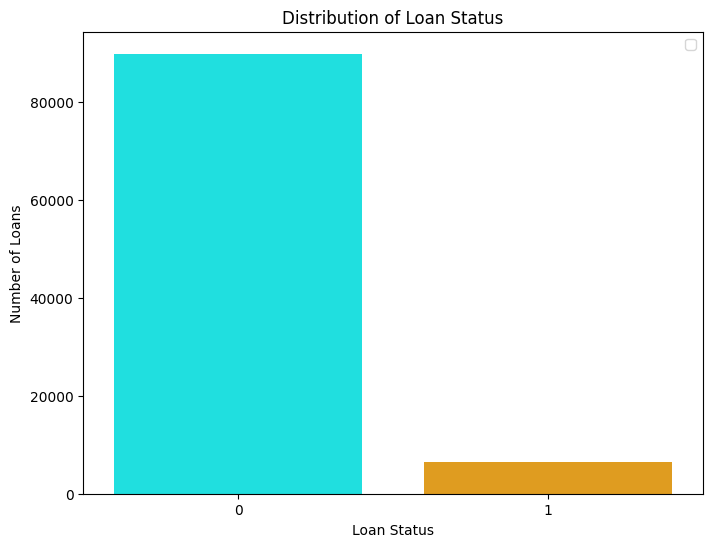

In [70]:
plt.figure(figsize=(8, 6))
sns.countplot(data=Loan_df, x='Loan Status', palette= ('cyan', 'orange'))
plt.title('Distribution of Loan Status')
plt.ylabel('Number of Loans')
plt.xlabel('Loan Status')
plt.legend()
plt.show()


### *   0 - This refers that the loan has not been Defaulted.
### *   1 - This refers that the loan has been Defaulted.

### By observing the plot we can see that there is a huge imbalance of loan status distribution. The Non-Defaulted class has high number of entries than the Defaulted class. The trained model may get biased towards the majority class, therefore we need to handle this class imbalance.


---





### The result of the following code gives us various plots, illustrating the distribution of certain numerical features.








<ipython-input-71-ca97238f961a>:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap('turbo')


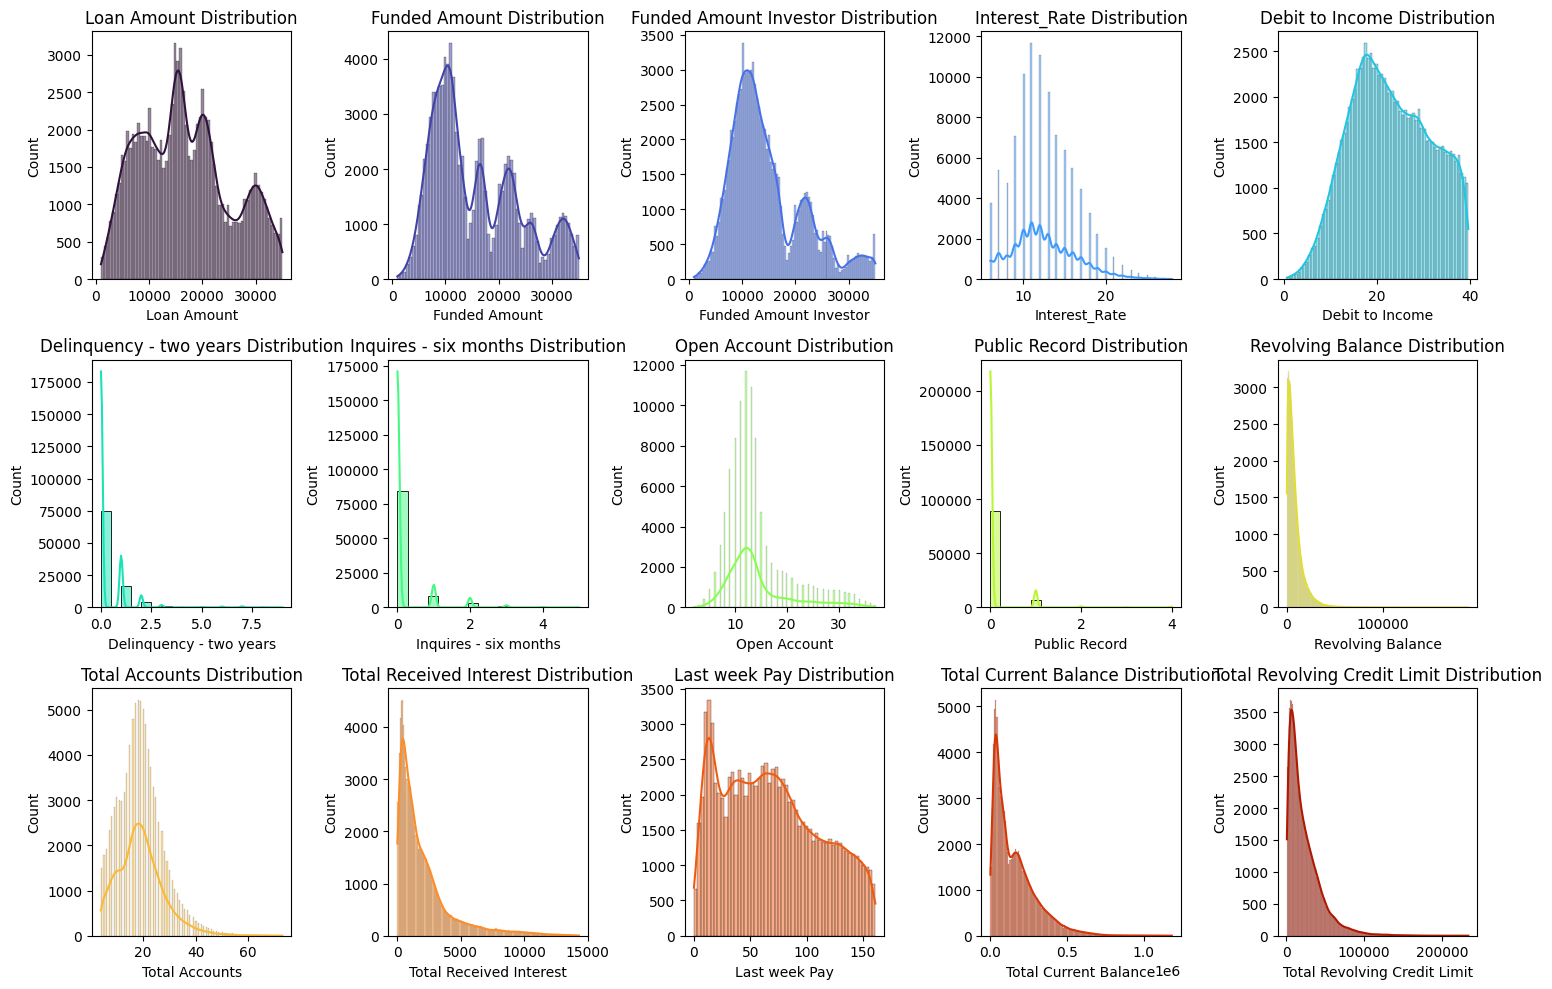

In [71]:
columns = ['Loan Amount', 'Funded Amount', 'Funded Amount Investor', 'Interest_Rate',
           'Debit to Income', 'Delinquency - two years', 'Inquires - six months', 'Open Account',
           'Public Record', 'Revolving Balance', 'Total Accounts', 'Total Received Interest',
           'Last week Pay', 'Total Current Balance', 'Total Revolving Credit Limit']

colormap = cm.get_cmap('turbo')
num_cols = len(columns)
num_rows = 3
fig, axs = plt.subplots(num_rows, num_cols // num_rows, figsize=(15, 10))
plt.subplots_adjust(wspace=0.5, hspace=0.5)

for i, col in enumerate(columns):
    sns.histplot(x=Loan_df[col], kde=True, color=colormap(i/num_cols), ax=axs[i // (num_cols // num_rows), i % (num_cols // num_rows)])
    axs[i // (num_cols // num_rows), i % (num_cols // num_rows)].set_title(col + ' Distribution')
plt.tight_layout()
plt.show()


### *   There is a Normal Distribution in the features Loan Amount, Funded Amount, Funded Amount Investor, Interest Rate, Debit to Income, Open Accounts, Total Accounts and Last week Pay.
### *  The distribution is normal, indicating that the data is not significantly skewed. This suggests that the outliers are not too far out from the mean, and that the distribution is fairly symmetric.

### *  Features such as Revolving Balance, Total received Interest, Total current Balance and Revolving credit limit, their distribution is skewed to the left.


---



### Let's Observe the distribution of '**Term**' feature. This mainly refers the duration of the loan repayment.


Text(0.5, 1.0, 'Distribution of Term')

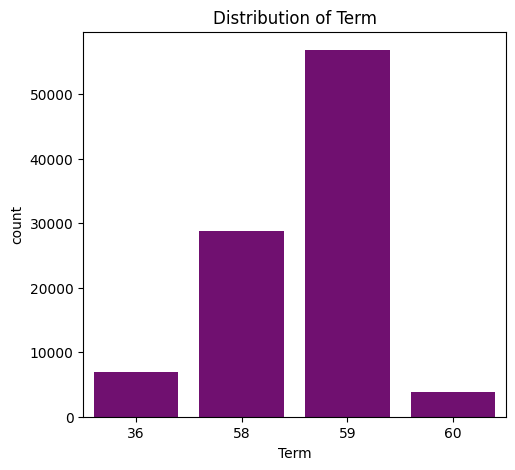

In [72]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=Loan_df, x='Term', color = 'purple')
plt.title('Distribution of Term')

### From the above plot we can see here that that the mean of the distribution lies around 56 to 59 months, this tells us that the average loan repayment duration is 5 years.

---



### Analyzing '**Loan Amount**' feature. There are certain things that we can note here.

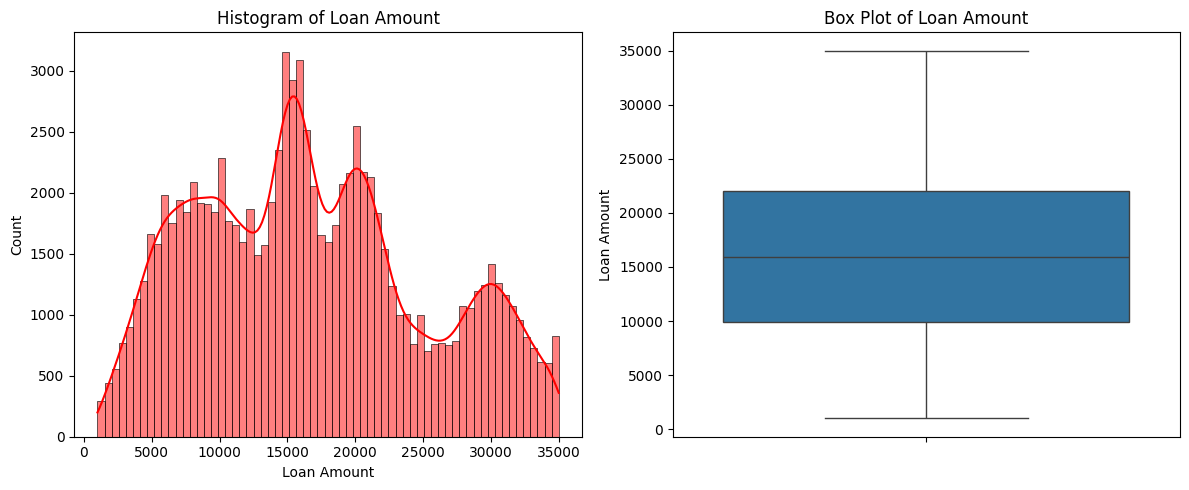

In [73]:
# Plot histogram for 'Loan Amount'
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=Loan_df, x='Loan Amount', kde=True, color = 'red')
plt.title('Histogram of Loan Amount')

# Plot box plot for 'Loan Amount'
plt.subplot(1, 2, 2)
sns.boxplot(data=Loan_df, y='Loan Amount')
plt.title('Box Plot of Loan Amount')

plt.tight_layout()
plt.show()


### *   The feature "Loan Amount" in the dataset is uniformly distributed, with no notable skewness found.

### *   Additionally there are no outliers present.

### *  Absence of outliers suggests that the Loan Amounts requested by the applicants are within a reasonable range and hence also do not deviate significantly form the majority of the data.


---



### Now let's look into the '**Interest Rate**' feature.

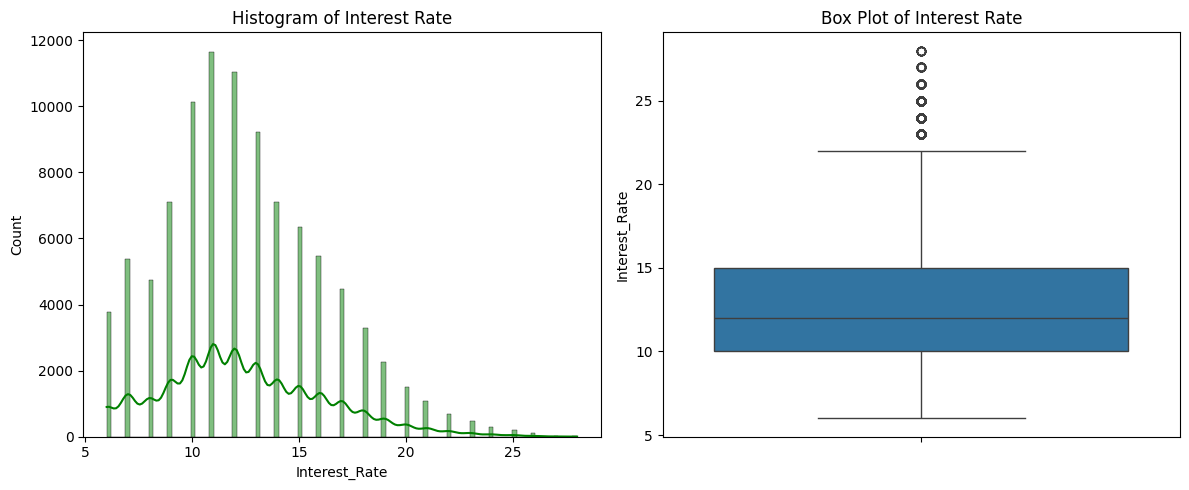

In [74]:
# Plot histogram for 'Interest Rate'
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=Loan_df, x='Interest_Rate', kde=True, color = 'green')
plt.title('Histogram of Interest Rate')

# Plot box plot for 'Interest Rate'
plt.subplot(1, 2, 2)
sns.boxplot(data=Loan_df, y='Interest_Rate')
plt.title('Box Plot of Interest Rate')

plt.tight_layout()
plt.show()


### *   By observing the histogram we can see that the distribution is Right Skewed.
### *   There are also evidence of Outliers being present.
### *  Presence of Outliers indicates that there are applicants who have very high Interest Rates. This completely makes sense because there are applicants who have very bad Credit History, History of Delinquencies and Defaults.


---







In [75]:
Categorical_df =Loan_df[['Loan Amount','Funded Amount',"Funded Amount Investor",'Term','Interest_Rate','Debit to Income'
          ,'Delinquency - two years',"Inquires - six months","Open Account","Public Record",'Revolving Balance'
          ,'Total Accounts','Total Received Interest',"Total Received Late Fee",'Recoveries',
          'Collection Recovery Fee','Last week Pay','Accounts Delinquent',"Total Collection Amount",
          "Total Revolving Credit Limit"]].copy()

## Correlation Matrix
### If features are highly co-related then they tend to give the same information to the model, so we try to identify the higly co-related features and eliminate one of them

<Axes: >

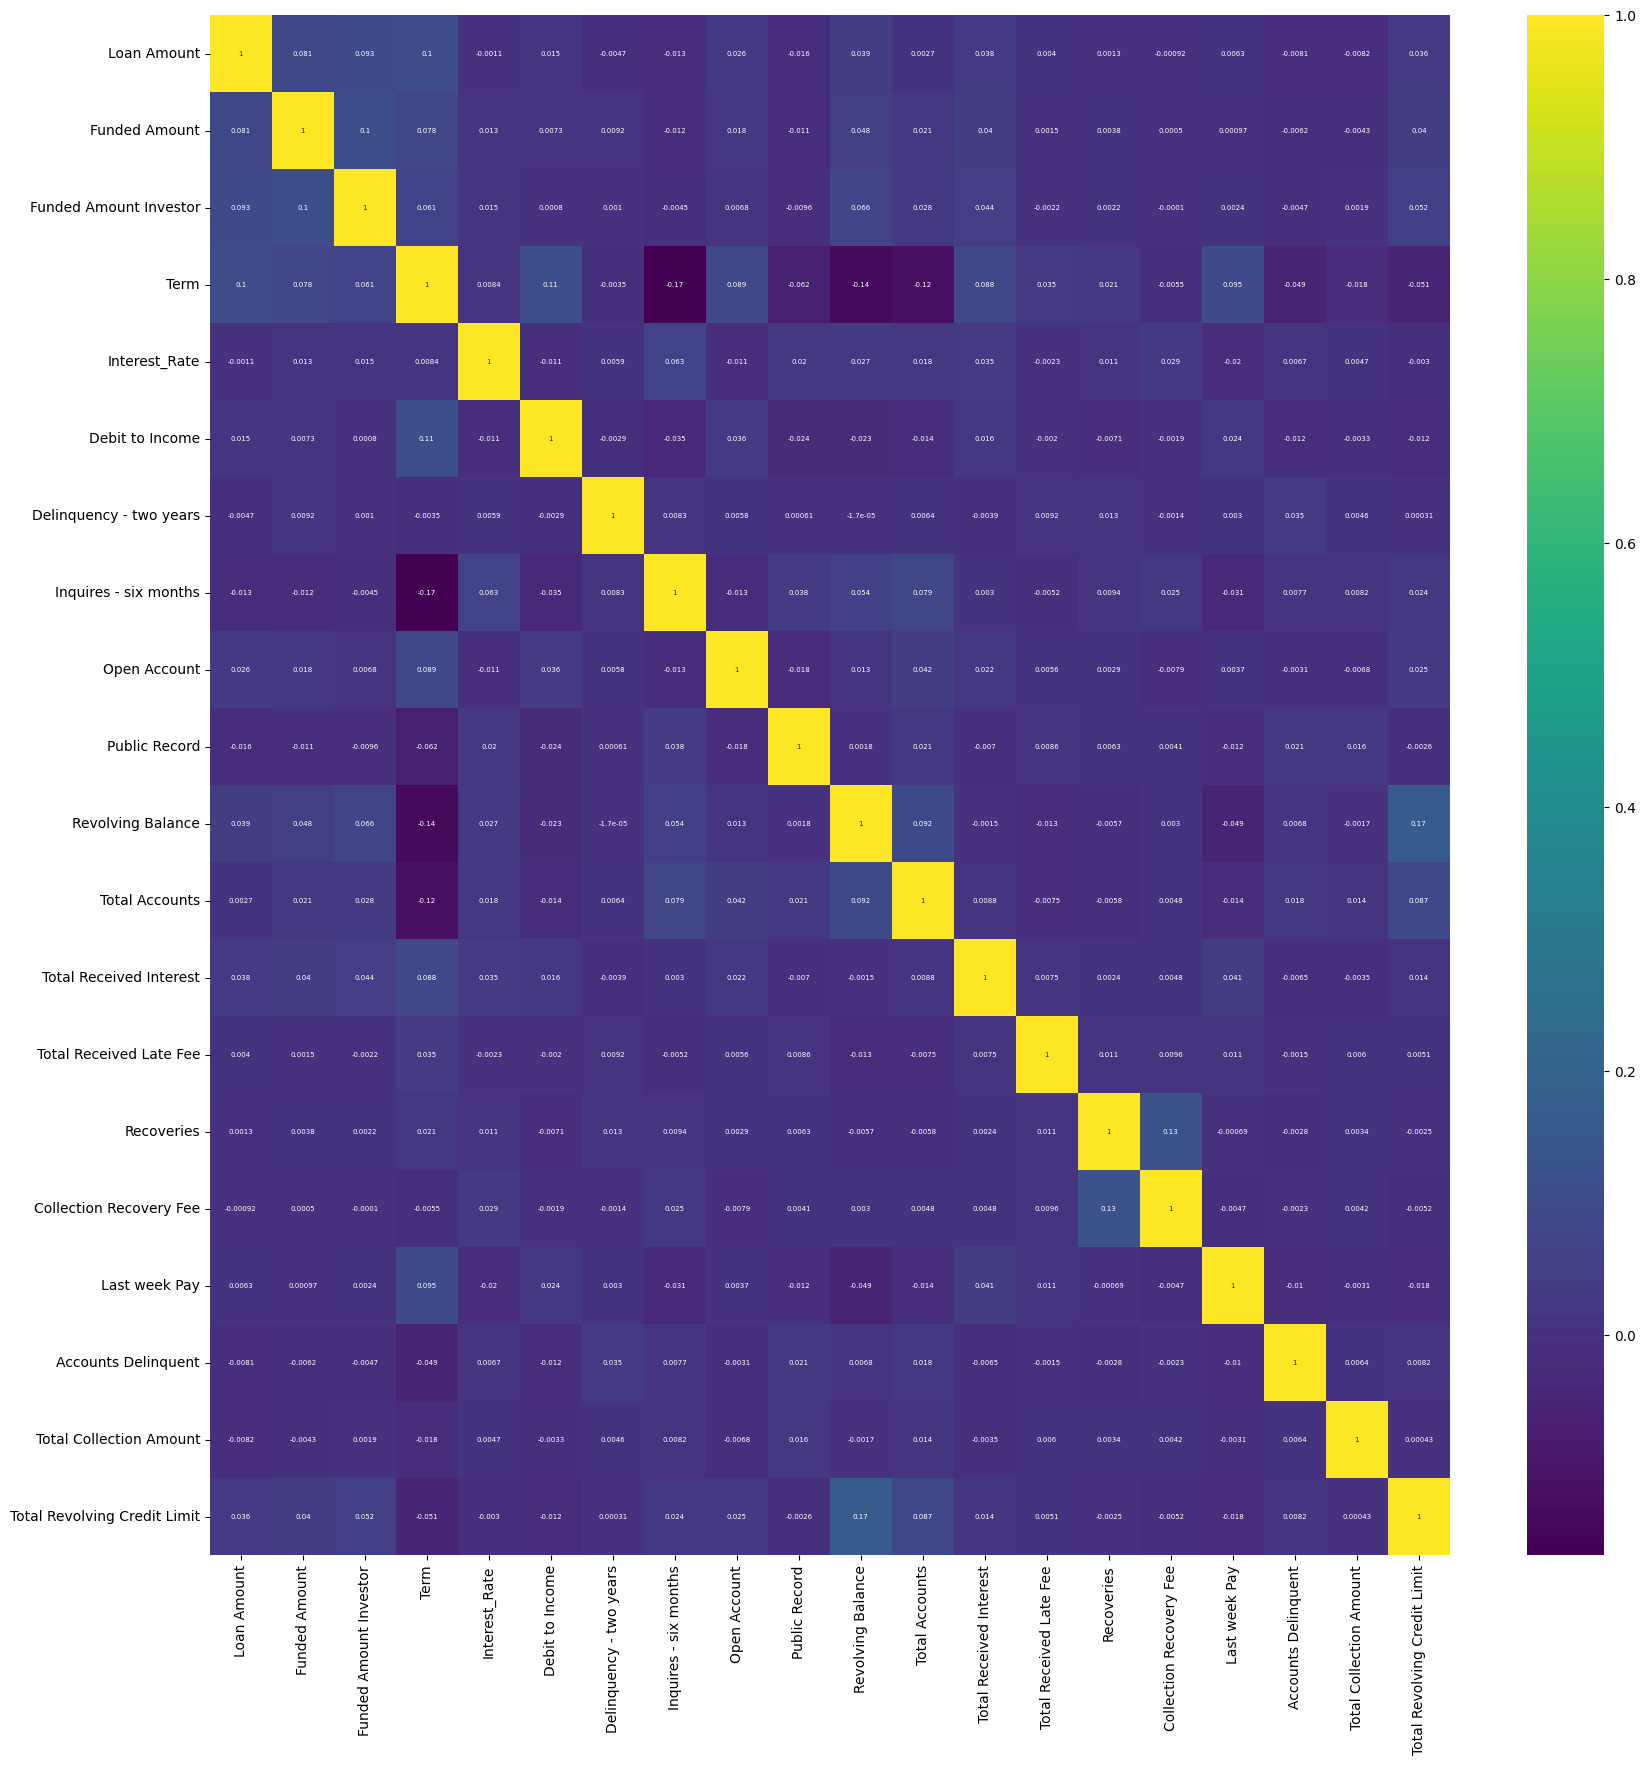

In [76]:
corr = Categorical_df.corr()
plt.figure(figsize=(20,20))
sns.heatmap(corr, cmap = 'viridis', annot= True,annot_kws={"size":5})

### Through the below obtained results we can observe that there are no features that are highly correlated.

In [77]:
#finding correlated features
def corelation(diabetics_df, threshold):
  col_corr = set() #all correlated columns
  corr_matrix = diabetics_df.corr()
  for r in range (len(corr_matrix.columns)):
    for s in range(r):
      if (corr_matrix.iloc[r,s]) > threshold:
        colname = corr_matrix.columns[r]
        col_corr.add(colname)
  return col_corr

### Here we have set the Correlatiion threshold at 0.8. So if there are any values that are higher that 0.8 then those features can be considered as highly correlated. But we observe that there are zero (0) highly correlated features.

In [78]:
corr_features = corelation(Categorical_df, 0.8)
len(set(corr_features))

0

##    What is the distribution of '**Grade**' Feature?
### *   The following plot describes the number of loan applications that have been categorized into various grades starting from A to G.




<ipython-input-79-cce273eb6090>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Grade', data=Loan_df, order= grade_order, palette='Set1')


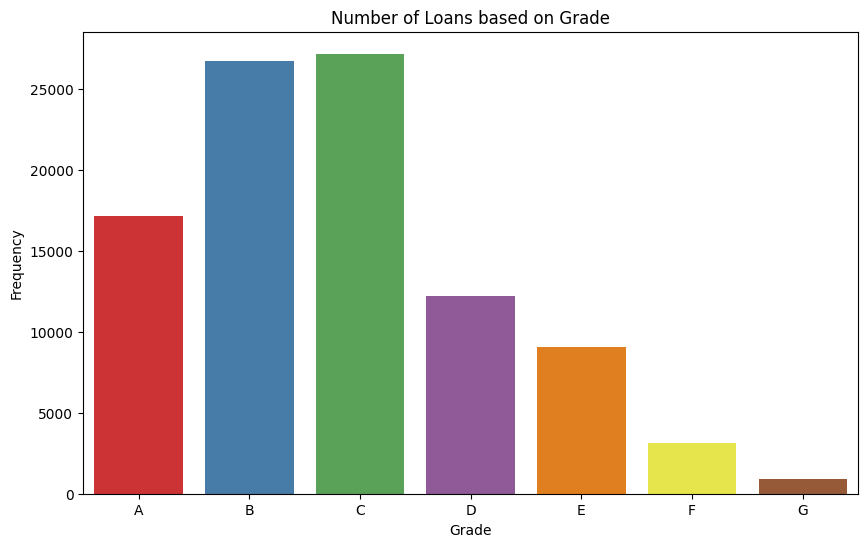

In [79]:
plt.figure(figsize=(10, 6))
grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

sns.countplot(x='Grade', data=Loan_df, order= grade_order, palette='Set1')
plt.title('Number of Loans based on Grade')
plt.xlabel('Grade')
plt.ylabel('Frequency')
plt.show()

### * Here Grade A has the safest applicants and subsequntly the risk factor increases thus Grade G comprises of the riskiest applicants.

### * We can also observe that Grades "B" and "C" are associated with the highest number of loans.The plot majorly highlights the importance of the Grades suggesting that certain Grades may influence the likelihood of loan approval.


---



# Bivariate Analysis




## What is the relationship between 'Loan Amount' and 'Interest Rate' features?

<Figure size 1000x600 with 0 Axes>

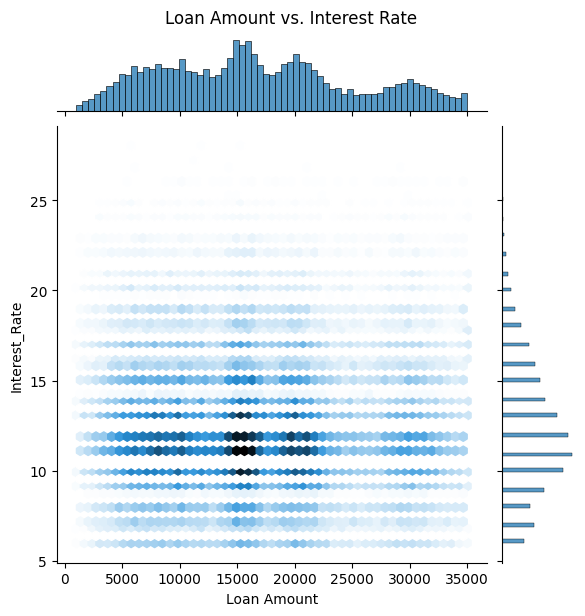

In [80]:
plt.figure(figsize=(10, 6))
sns.jointplot(x='Loan Amount', y='Interest_Rate', data=Loan_df, kind='hex')
plt.suptitle('Loan Amount vs. Interest Rate', y=1.02)
plt.show()

### *   By observing the above plot, we can infer that that the Loan Amount has a uniform distribution against the Interest Rate.
### *   We can observe a dense concentration in Loan Amount between 15,000 to 20,000 it indicates the average Loan Amount requested by the applicants, correspondingly the 'Interest Rate' mean also lies in the same region, that's in between 10% to 15%.


---





## What is the 'Loan Status' Based on 'Interest Rate'?

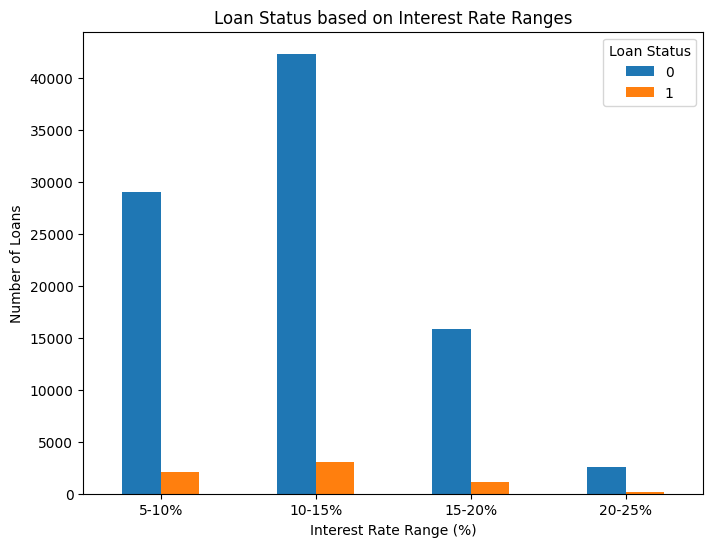

In [81]:
interest_rate_ranges = [(5, 10), (10, 15), (15, 20), (20,25)]
Loan_df['Interest Rate Range'] = pd.cut(Loan_df['Interest_Rate'], bins=[5, 10, 15, 20, 25], labels=['5-10%', '10-15%', '15-20%', '20-25%'])
interest_status_counts = Loan_df.groupby(['Interest Rate Range', 'Loan Status']).size().unstack(fill_value=0)

interest_status_counts.plot(kind='bar', stacked=False, figsize=(8, 6))
plt.title('Loan Status based on Interest Rate Ranges')
plt.xlabel('Interest Rate Range (%)')
plt.ylabel('Number of Loans')
plt.xticks(rotation=0)
plt.legend(title='Loan Status', loc='upper right')
plt.show()

### *   The above mentioned plot describes the Loan Status based on the certain intervals of Interest rates. we can clearly see that 10-15% category has the hightest number of loan applications and as well as the highest number of non-defaults.
### *   As our target variable is Imbalanced, the distribution only favours the majority class, i.e Loan Non Default class. But we can still observe decent amount of Loan Defaults in the first 3 categories.


---




## What is the Status of the Loan Based on the Grades?

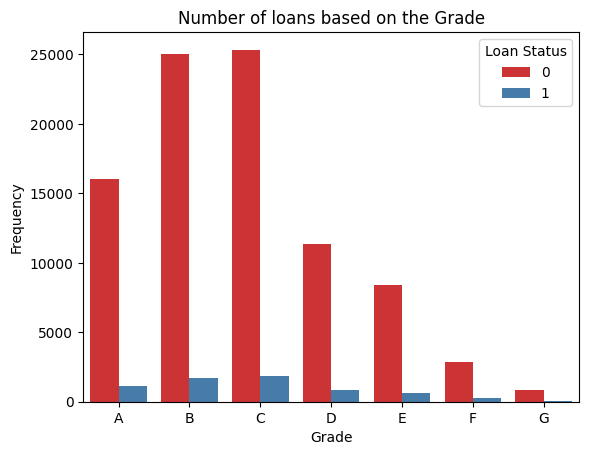

In [82]:
sns.countplot(x='Grade', hue="Loan Status",order = grade_order,data=Loan_df, palette = 'Set1')
plt.title("Number of loans based on the Grade")
plt.xlabel('Grade')
plt.ylabel('Frequency')
plt.show()

### *   By viewing the above bar graph we can see the distribution of the 'Loan Status' based on the various categories of Grades.
### *   As mentioned in earlier discussions, Grades have a significant impact on the approval of the Loan. Garde A comprises of the safest applicants and subsequently the risk factor increases as Grade G consists of the riskiest applicants.

### *   Here we can see that most of the approved loans have been from Grades A, B and C. These 3 Grades combine to form more than 80 percent of the Loan Applications.


---







## What are the distribution of Whole and Fractional Loans?

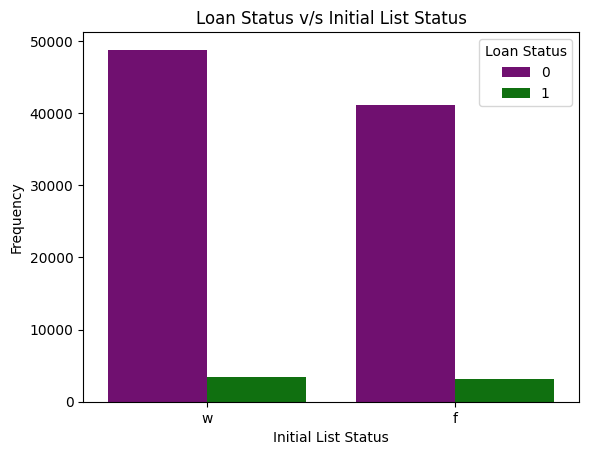

In [83]:
custom_palette = { 'green', 'purple'}
sns.countplot(x='Initial List Status', hue="Loan Status",data=Loan_df, palette=custom_palette)
plt.title("Loan Status v/s Initial List Status")
plt.xticks(size=10)
plt.xlabel('Initial List Status')
plt.ylabel('Frequency')
plt.show()


### *   In the above displayed plot we can observe that 'Whole Loan' occupies  about 60 percent of the distribution. It refers to a loan that is funded by a single investor.
### *   But we can observe on thing that, though there are more nummber of 'Whole' loans than 'Fractional' loans, the loans that have been defaulted under fractional loans have been almost equal to whole loans. Fractional loans signifies the instances where multiple Investors contribute to fund a portion of the Loan. So there are more chances for loan defaults.


---




## What is the verification status of whole and fractional loans?

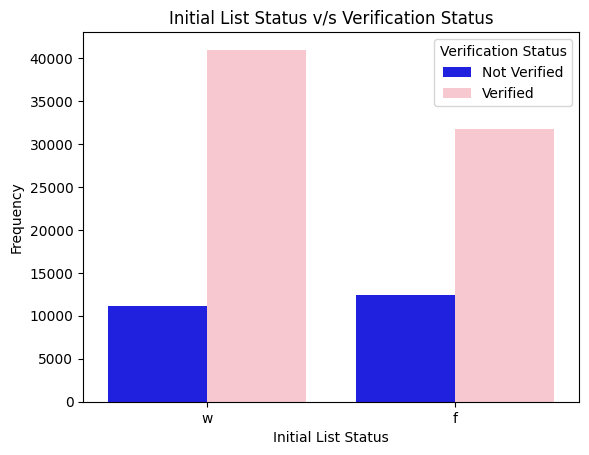

In [84]:
custom_palette = {'pink', 'blue'}
sns.countplot(x='Initial List Status', hue="Verification Status",data=Loan_df, palette=custom_palette)
plt.title("Initial List Status v/s Verification Status")
plt.xticks(size=10)
plt.xlabel('Initial List Status')
plt.ylabel('Frequency')
plt.show()


### *   By viewing the above chart we can see that 'Fractional' Loans have more percent of 'Not Verified' Loan applications than 'Whole' loans.
### *  This signifies the fact that 'Fractionl' loans applicants are more likely to default their loans.


---





## What is the variation of Loan Amount based on the Status of the Loan?

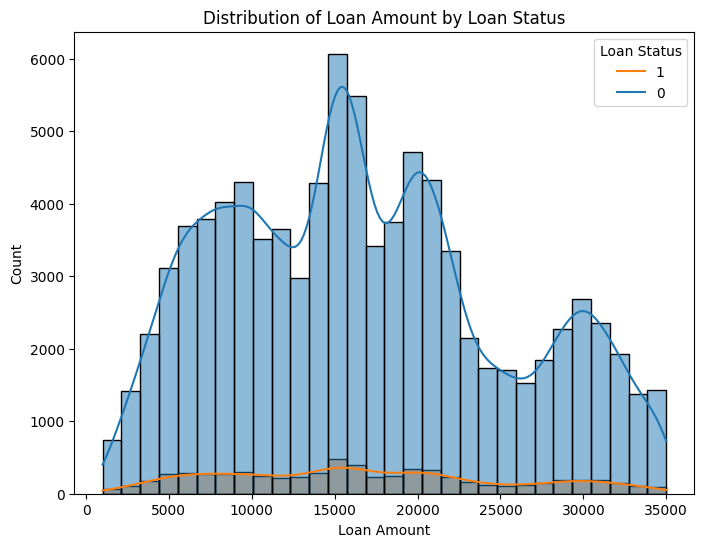

In [85]:
plt.figure(figsize=(8, 6))
sns.histplot(data=Loan_df, x='Loan Amount', bins=30, kde=True, hue='Loan Status')
plt.title("Distribution of Loan Amount by Loan Status")
plt.xlabel("Loan Amount")
plt.ylabel("Count")
plt.legend(title="Loan Status", labels=["1", "0"])
plt.show()

### *   The above plot illustrates the relationship between Loan Amount and Loan Status.
### *   We can observe that the Loan Amount has a normal distribution without any skewness. The status of the loan that are defaulted and non-defaulted vary accordingly. We can observe that Loan Defaults are present for almost all the values of Loan Amount.

### *  This gives us an insight that an applicant may default his or her loan based on any value of the loan amount. It need not only be higher loan amount, there are defaults present even in the lower amounts sections.


---






##How does Home ownership status have impact on the status of the loan?

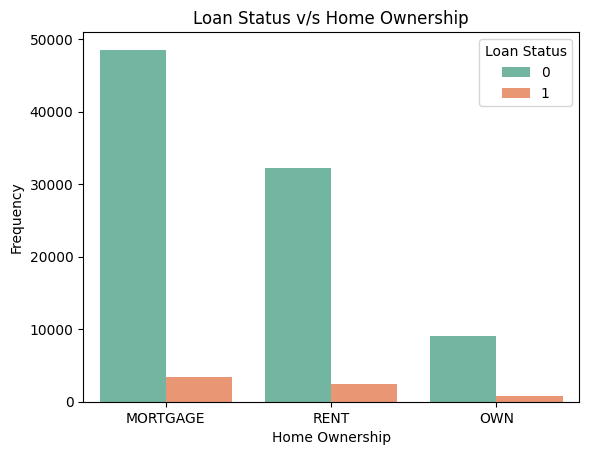

In [86]:
sns.countplot(x='Home Ownership', hue="Loan Status",data=Loan_df, palette = 'Set2')
plt.title("Loan Status v/s Home Ownership")
plt.xticks(size=10)
plt.xlabel('Home Ownership')
plt.ylabel('Frequency')
plt.show()


### *   Based on the above displayed plot we can see that the Home ownership has 3 major categories they are Mortgage, Rent and Own.
### *   Here we can observe that People who have Mortgages and and people who are paying Rents comprise of almost 85 perecnt of the loan applications.
### * This makes complete sense, as people with mortgages would have requested Home loans.
### * Another factor that can be observed is that people with Own house have less number of loan applications, this acts as an evidence as that they have stable income and are well settled. Therfore they would also be having lower Loan Interest Rates when compared with other groups. Thus Home Ownership plays a significant role in the entire Loan process.


---





## What percentage of Loan Applications are verified?

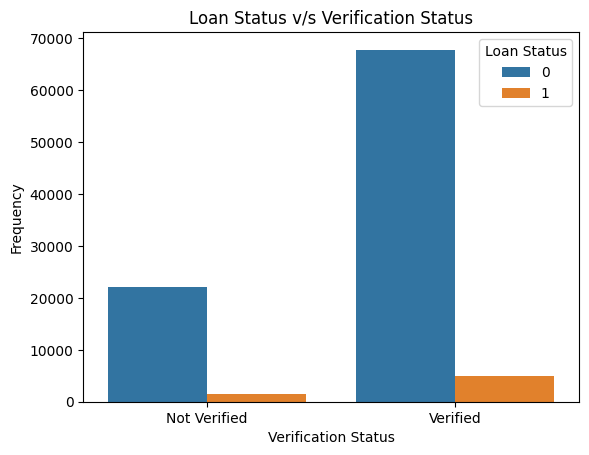

In [87]:
sns.countplot(x='Verification Status', hue="Loan Status",data=Loan_df)
plt.title("Loan Status v/s Verification Status")
plt.xticks(size=10)
plt.xlabel('Verification Status')
plt.ylabel('Frequency')
plt.show()


### Here we can observe that there are 2 categories,


### *   Verified - It refers to whether the lender has verified the information provided by the borrower. For example through Pay slips, Tax returns or Bank Statements.
### *   Not Verified - This implies that the lender has not verified the information provided by the borrower.

### Here we can also note that almost 70 percent of the loan applications are verified. But the presence of 30 percent of unverified applications increases the chances of Loan Defaults.


---








# **Modelling and Model Evaluation**

### Now let's transform the Categorical Features using label encoder.

In [89]:
le = LabelEncoder()

categorical_features = ['Batch Enrolled','Grade', 'Sub Grade', 'Home Ownership', 'Verification Status',
                        'Loan Title', 'Initial List Status', 'Application Type']

for i in categorical_features:
    Loan_df[i] = le.fit_transform(Loan_df[i])

In [90]:
Loan_df.shape

(96376, 36)

In [91]:
Loan_df.head()

,index,ID,Loan Amount,Funded Amount,Funded Amount Investor,Term,Batch Enrolled,Interest_Rate,Grade,Sub Grade,...,Collection Recovery Fee,Collection 12 months Medical,Application Type,Last week Pay,Accounts Delinquent,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit,Loan Status,Interest Rate Range
0,0,65087372,10000,32236,12329.36286,59,16,12,1,13,...,0.793724,0,0,49,0,31,311301,6619,0,10-15%
1,1,1450153,3609,11940,12191.99692,59,4,13,2,17,...,0.974821,0,0,109,0,53,182610,20885,0,10-15%
2,2,1969101,28276,9311,21603.22455,59,11,13,5,18,...,1.020075,0,0,66,0,34,89801,26155,0,10-15%
3,3,6651430,11170,6954,17877.15585,59,15,17,2,12,...,0.749971,0,0,39,0,40,9189,60214,0,15-20%
4,4,14354669,16890,13226,13539.92667,59,32,16,2,18,...,0.368953,0,0,18,0,430,126029,22579,0,15-20%


### It is always better to delete unwanted features.

In [92]:
del Loan_df['Interest Rate Range']
del Loan_df['index']

In [93]:
Loan_df.shape

(96376, 34)

In [94]:
Loan_df['Loan Status'].value_counts()

Loan Status
0    89870
1     6506
Name: count, dtype: int64

In [95]:
#Splitting data into X and y
X =Loan_df.drop('Loan Status', axis=1)
y =Loan_df['Loan Status']

In [96]:
X.shape

(96376, 33)

In [97]:
y.shape

(96376,)

# Handling Class Imbalance

### * As observed previously, the Target feature had High level of Class Imbalance. This would influence the performance of the machine learning model as the model could be biased towards the majority class, which is not desired.
### *  Therefore we need to Balance the Minority class. Here we make use of **SMOTE** [ Synthetic Minority Over-sampling Technique ]. SMOTE balances the minority class by performing Data Interpolation using K nearest neighbours (Knn). The generated Synthetic Instances are used to balance the minority class. Therefore this will improve the performance of machine learning models that are sensitive to class imbalance



In [98]:
smote = SMOTE()

# Now we can fit and resample the data
X, y = smote.fit_resample(X, y)

## Identifying Feature Importance
### Here we can observe the importance of each feature. Random Forest classifier is trained on the entire train dataset, and as a result we can visualize the impact of each feature on the response variable.

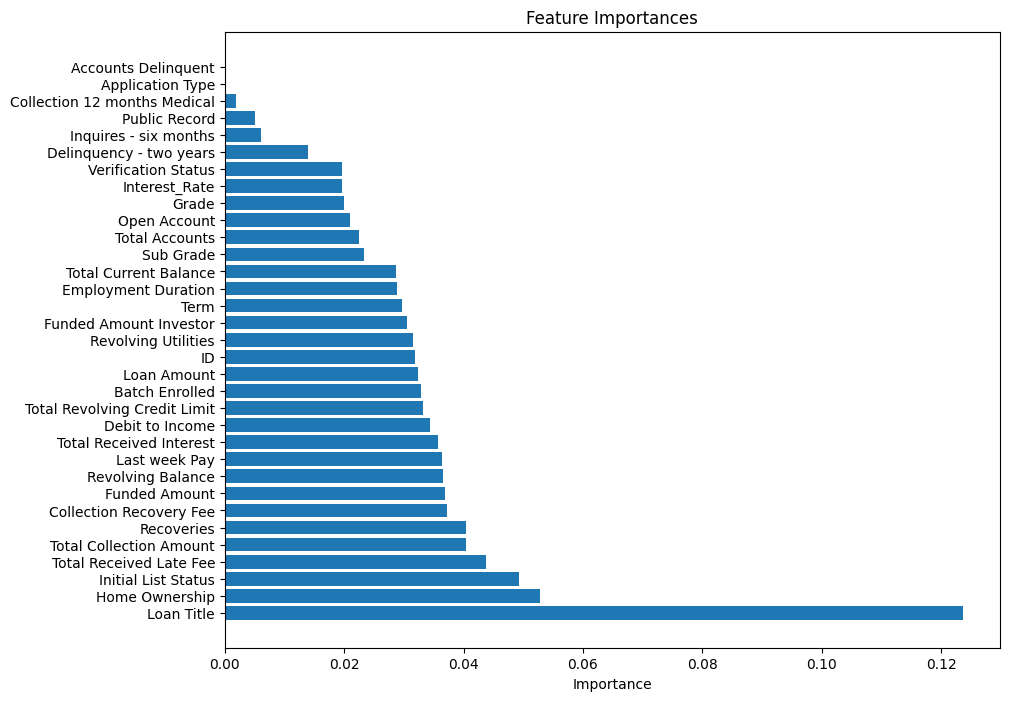

In [100]:
rfc_model = RandomForestClassifier(random_state=42)
rfc_model.fit(X, y)

feature_importances = rfc_model.feature_importances_
features = X.columns
indices = np.argsort(feature_importances)[::-1]
plt.figure(figsize=(10,8))
plt.title("Feature Importances")
plt.barh(range(X.shape[1]), feature_importances[indices])
plt.yticks(range(X.shape[1]), features[indices])
plt.xlabel('Importance')
plt.show()

## Now the Machine Learning Models will be trained using '**Hold-out**' Method

### Let's split up the Dataset into 2 Subsets, Training and Testing Set.

In [101]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [102]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((143792, 33), (35948, 33), (143792,), (35948,))

## Feature Scaling
### Here we perform feature scaling so that the model gives same importance to all features, this prevents the dominance of features with higher scale over features with lower scale.

In [103]:
# Standardize the input features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Baseline Model - Logistic Regression

### It's a straightforward but effective technique for binary classification tasks such as loan default prediction. Logistic regression provides probabilistic interpretations and is effective with linearly separable data.

### Since it's the Baseline model, even a stratified k-fold cross validation has been performed on the model.

In [104]:
log_reg = LogisticRegression()

# Here we initialize Stratified K-Fold cross-validator
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(log_reg, X_train, y_train, cv=skf, scoring='accuracy')

print("Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


Cross-Validation Scores: [0.68260371 0.68124761 0.68099311 0.68061061 0.68339245]
Mean CV Accuracy: 0.6817694982174275


In [105]:
# Train a Logistic regression model on Train set.
log_reg.fit(X_train, y_train)

LogisticRegression()

In [106]:
# predict the results on train set and obtain training accuracy
y_pred_logt = log_reg.predict(X_train)

accuracy_logt = accuracy_score(y_train, y_pred_logt)
print(accuracy_logt)

0.6818459997774563


In [107]:
# Predict labels for the test data
y_pred_log = log_reg.predict(X_test)

In [108]:
# Evaluate the model performance
print(confusion_matrix(y_test, y_pred_log))
accuracy_log = accuracy_score(y_test, y_pred_log)
print(accuracy_log)

# Create the classification report
report = classification_report(y_test, y_pred_log)

print("Classification Report:\n", report)

[[11828  6176]
 [ 5374 12570]]
0.6787025703794369
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.66      0.67     18004
           1       0.67      0.70      0.69     17944

    accuracy                           0.68     35948
   macro avg       0.68      0.68      0.68     35948
weighted avg       0.68      0.68      0.68     35948



In [109]:
# Calculate the F1 score
f1_log = f1_score(y_test, y_pred_log)
f1_percentage = f1_log * 100

print("F1 Score:", f1_log)
print("F1 Score (Percentage): {:.2f}%".format(f1_percentage))

F1 Score: 0.6852003270645953
F1 Score (Percentage): 68.52%


# Gaussian Naive Bayes

### Naive Bayes algorithms are known for their simplicity and efficiency. Gaussian Naive Bayes assumes that features are independent and follow a Gaussian distribution, making it suitable for numerical data.

In [110]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [111]:
# predict the results on train set and obtain training accuracy
y_pred_gnbt = nb_model.predict(X_train)

accuracy_gnbt = accuracy_score(y_train, y_pred_gnbt)
print(accuracy_gnbt)

0.5516857683320352


In [112]:
# Predict the test set results
y_pred_gnb = nb_model.predict(X_test)

In [113]:
print(confusion_matrix(y_test, y_pred_gnb))
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
print(accuracy_gnb)

# Create the classification report
report = classification_report(y_test, y_pred_gnb)

print("Classification Report:\n", report)

[[ 2463 15541]
 [  561 17383]]
0.5520752197618782
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.14      0.23     18004
           1       0.53      0.97      0.68     17944

    accuracy                           0.55     35948
   macro avg       0.67      0.55      0.46     35948
weighted avg       0.67      0.55      0.46     35948



In [114]:
# Calculate the F1 score
f1_gnb = f1_score(y_test, y_pred_gnb)
f1_percentage = f1_gnb * 100

print("F1 Score:", f1_gnb)
print("F1 Score (Percentage): {:.2f}%".format(f1_percentage))

F1 Score: 0.6834552174254933
F1 Score (Percentage): 68.35%


# Decision Tree

### Decision trees are interpretable and can handle both numerical and categorical data. They can capture nonlinear relationships and interactions between features. Therefore a model was trained using Decision Trees.

In [115]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [116]:
# predict the results on train set and obtain training accuracy
y_pred_dtt = dt_model.predict(X_train)

accuracy_dtt = accuracy_score(y_train, y_pred_dtt)
print(accuracy_dtt)

1.0


In [117]:
# Predict the test set results
y_pred_dt = dt_model.predict(X_test)

In [118]:
# Evaluate the model performance
print(confusion_matrix(y_test, y_pred_dt))
print(accuracy_score(y_test, y_pred_dt))

# Create the classification report
report = classification_report(y_test, y_pred_dt)

print("Classification Report:\n", report)

[[14312  3692]
 [ 2432 15512]]
0.8296428174029153
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.79      0.82     18004
           1       0.81      0.86      0.84     17944

    accuracy                           0.83     35948
   macro avg       0.83      0.83      0.83     35948
weighted avg       0.83      0.83      0.83     35948



In [119]:
# Calculate the F1 score
f1_dt = f1_score(y_test, y_pred_dt)
f1_percentage = f1_dt * 100

print("F1 Score:", f1_dt)
print("F1 Score (Percentage): {:.2f}%".format(f1_percentage))

F1 Score: 0.8351459028749866
F1 Score (Percentage): 83.51%


#   Enemble Learning - Random Forest

### Random Forest is a decision tree based ensemble learning technique. It improves performance and minimizes overfitting by combining several decision trees. It's robust to outliers and noise in the data.

In [120]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [121]:
y_pred_rft = rf_model.predict(X_train)
accuracy_rft = accuracy_score(y_train, y_pred_rft)
print(accuracy_rft)

0.9999930455101814


In [122]:
# Predict the test set results
y_pred_rf = rf_model.predict(X_test)

In [123]:
# Evaluate the model performance
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(accuracy_rf)

# Create the classification report
report = classification_report(y_test, y_pred_rf)

print("Classification Report:\n", report)

0.9254756871035941
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93     18004
           1       0.94      0.91      0.92     17944

    accuracy                           0.93     35948
   macro avg       0.93      0.93      0.93     35948
weighted avg       0.93      0.93      0.93     35948



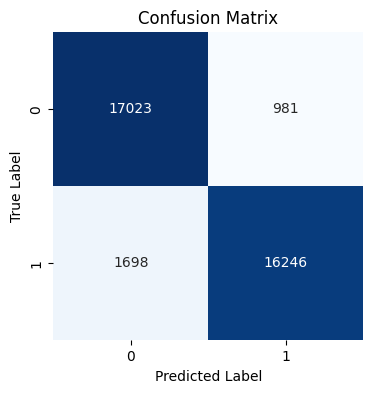

In [124]:
# Calculate Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_rf)

# Plot Confusion Matrix
plt.figure(figsize=(4, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [125]:
# Calculate the F1 score
f1_rf = f1_score(y_test, y_pred_rf)
f1_percentage = f1_rf * 100

print("F1 Score:", f1_rf)
print("F1 Score (Percentage): {:.2f}%".format(f1_percentage))

F1 Score: 0.9238292911773904
F1 Score (Percentage): 92.38%


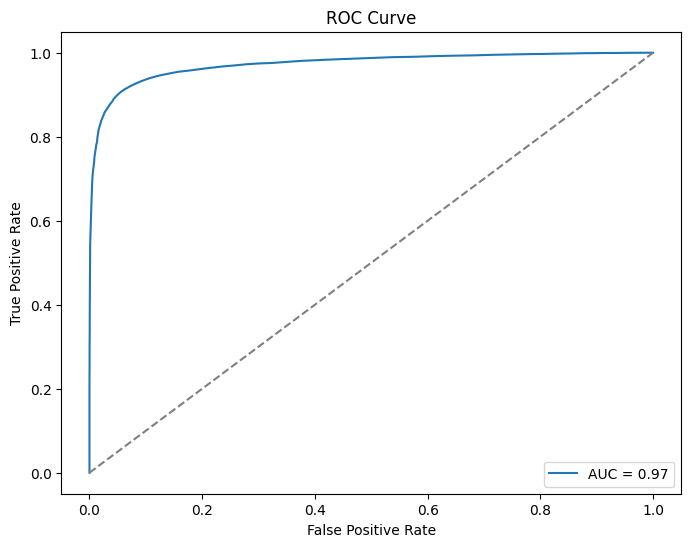

In [126]:
# Here we plot a ROC Curve
y_prob = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# **Final Model (Best Performing Model)**
# XGBoost

### XGBoost is an advanced gradient boosting algorithm that is well-known for its performance and scalability. It can handle huge datasets with complex feature relationships. Therefore this is the model that gave the best overall performance when compared with other models.


In [127]:
xgb_model = xgb.XGBClassifier(use_label_encoder = False, eval_metric='mlogloss', objective='multi:softmax', num_class=2, seed=42)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_class=2, num_parallel_tree=None, ...)

In [128]:
# predict the results on train set and obtain training accuracy
y_pred_xgbt = xgb_model.predict(X_train)

accuracy_xgbt = accuracy_score(y_train, y_pred_xgbt)
print(accuracy_xgbt)

0.9049947145877378


In [129]:
# Predict on Test set
y_pred_xgb = xgb_model.predict(X_test)

In [130]:
print(confusion_matrix(y_test, y_pred_xgb))
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(accuracy_xgb)

# Create the classification report
report = classification_report(y_test, y_pred_xgb)

print("Classification Report:\n", report)

[[16195  1809]
 [ 2404 15540]]
0.8828029375764994
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.90      0.88     18004
           1       0.90      0.87      0.88     17944

    accuracy                           0.88     35948
   macro avg       0.88      0.88      0.88     35948
weighted avg       0.88      0.88      0.88     35948



### True Positives (TP): There are 15610 cases where the model correctly predicted that the outcome is positive (e.g., predicted loan defaults correctly).

### False Positives (FP): There are 1798 cases where the model incorrectly predicted that the outcome is positive when it's actually negative (e.g., predicted a loan default when it didn't happen).

### False Negatives (FN): There are 2334 cases where the model incorrectly predicted that the outcome is negative when it's actually positive (e.g., failed to predict a loan default when it actually occurred).

### True Negatives (TN): There are 16206 cases where the model correctly predicted that the outcome is negative (e.g., predicted no loan default correctly).



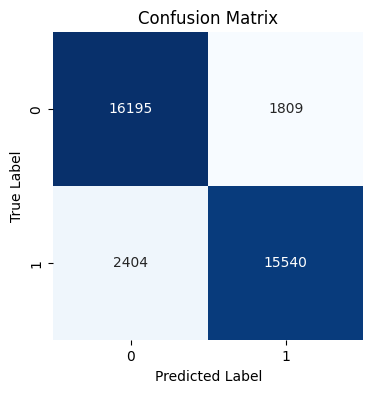

In [131]:
conf_matrix = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(4, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### **ROC** curve (Receiver Operator Characteristics), can be utilized in order to evaluate the performance of a machine learning model. The curve illustrates the trade-off between Sensitivity(True Positive Rate) and Specificity (Ture Negative Rate)

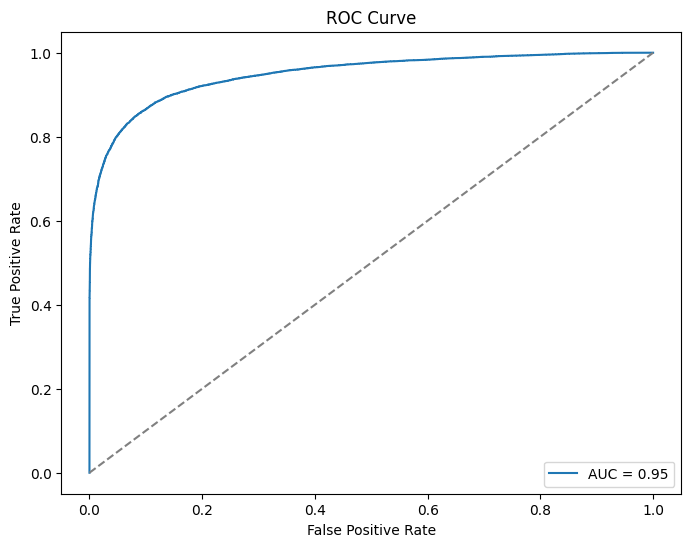

In [132]:
# Here we plot a ROC Curve
y_prob = xgb_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

In [133]:
# Calculate the F1 score
f1_xgb = f1_score(y_test, y_pred_xgb)
f1_percentage = f1_xgb * 100

print("F1 Score:", f1_xgb)
print("F1 Score (Percentage): {:.2f}%".format(f1_percentage))

F1 Score: 0.8806278865497408
F1 Score (Percentage): 88.06%


# Comparison of Training and Testing Accuracy for 5 ML models

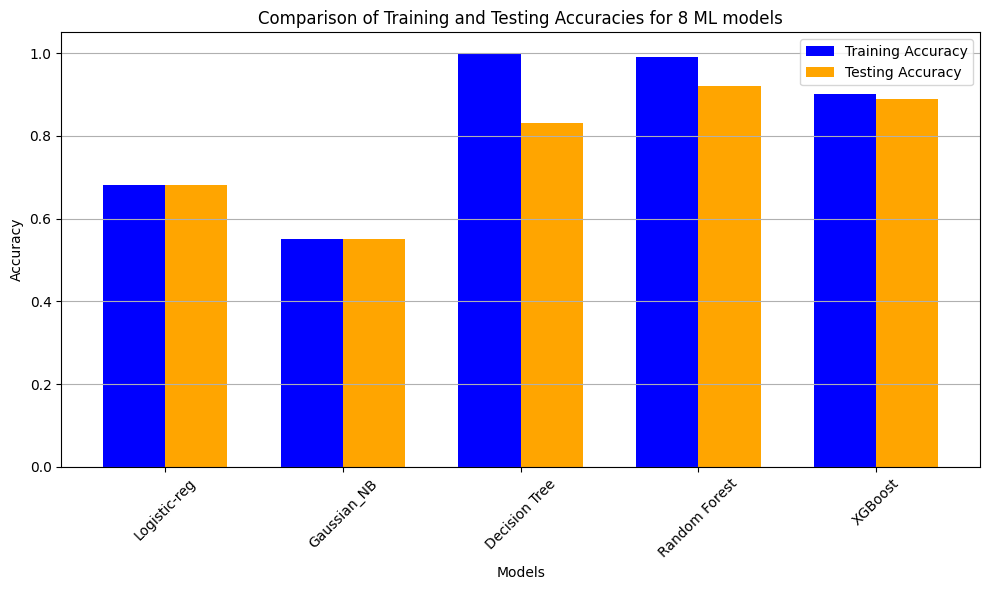

In [134]:
models = ['Logistic-reg', 'Gaussian_NB', 'Decision Tree', 'Random Forest', 'XGBoost']
training_accuracies = [0.68, 0.55, 1.0, 0.99, 0.90]
testing_accuracies = [0.68, 0.55, 0.83, 0.92, 0.89]
bar_width = 0.35
index = np.arange(len(models))

plt.figure(figsize=(10, 6))
plt.bar(index, training_accuracies, bar_width, label='Training Accuracy', color='blue')
plt.bar(index + bar_width, testing_accuracies, bar_width, label='Testing Accuracy', color='orange')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Comparison of Training and Testing Accuracies for 8 ML models')
plt.xticks(index + bar_width / 2, models, rotation=45)
plt.grid(axis='y')
plt.legend()


plt.tight_layout()
plt.show()


### By visualizing the above graph, we can observe many things. Here we are comparing the Training and Testing accuracy of 5 ML models.


### *   We can observe that there is some sort of overfitting in training accuracy for Decision Tree and Random Forest model.
### *    But when we compare the accuracies of Multi-Logreg, Gaussian_NB, and XGBoost we can notice that both training and testing accuracy are very similar.

### *   This means that the model is perfroming well on both train and test data. So therefore we can tell that the model has learnt the underlying patterns in the training data and is generalizing well to new or unseen data.

---



# Comparison of Testing Accuracy and F1 score for 5 ML models

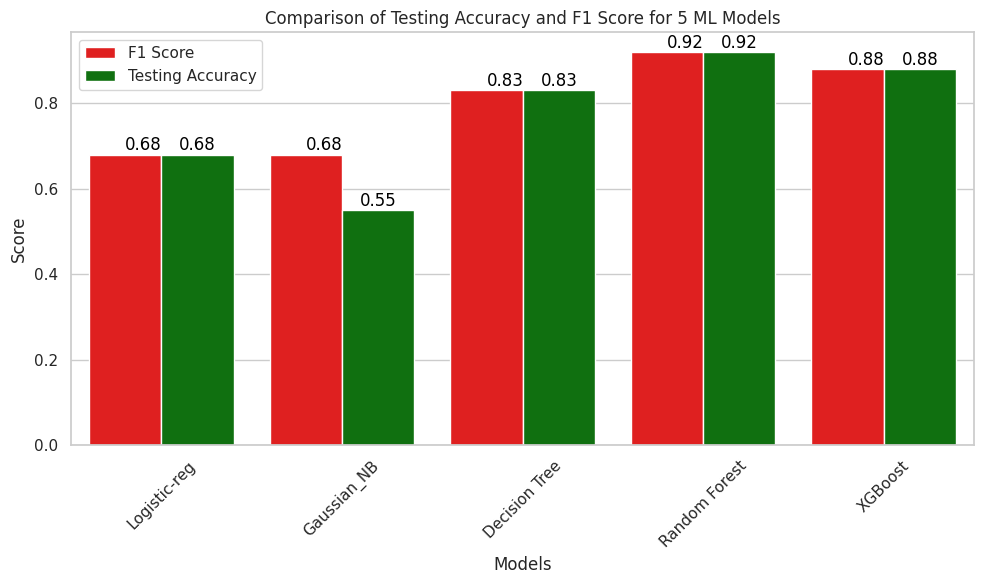

In [135]:
models = ['Logistic-reg', 'Gaussian_NB', 'Decision Tree', 'Random Forest', 'XGBoost']
f1_scores = [0.68, 0.68, 0.83, 0.92, 0.88]
testing_accuracies = [0.68, 0.55, 0.83, 0.92, 0.88]
data = pd.DataFrame({'Models': models, 'F1 Score': f1_scores, 'Testing Accuracy': testing_accuracies})
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(x='Models', y='value', hue='variable', data=pd.melt(data, ['Models']), palette=['red', 'green'])


for i, model in enumerate(models):
    plt.text(i - 0.2, f1_scores[i] + 0.01, f'{f1_scores[i]:.2f}', color='black')
    plt.text(i + 0.1, testing_accuracies[i] + 0.01, f'{testing_accuracies[i]:.2f}', color='black')

plt.title('Comparison of Testing Accuracy and F1 Score for 5 ML Models')
plt.xlabel('Models')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(title=None)
plt.tight_layout()
plt.show()


### Here we compare the testing accuracy and f1 scores, Random forest and decision trees are left out as the trainig accuracy is very high and it is overfitting the data. finally we can conclude that the best performing model, when compared with others **XGBoost**  has the highest testing accuracy of 0.88 (88%) and the highest f1 score of 0.88, since XGBoost refers to xtreme gradient boosting, it learns by assigning high weights to weak learners and finally improves the overall accuracy of the model.

# **Conclusion**



### *    The project focuses on establishing an accurate loan default prediction model.

### *   The absence of outliers in Loan Amount indicates that the that the Loan Amounts requested by the applicants are within a reasonable range.

### *   The presence of outliers in Interest Rates indicates applicants who have a very poor income, credit History and history of delinquencies.




### *  Fractional Loans have more chances for loan defaults than Whole loans, additionally Loan Title, Home Ownership and Verification status highly impacts the status of the loan.


### *   The model that gave the best overall performance when compared with other models is XGBoost.


### *   The project’s findings have implications for risk management procedures and can help financial institutions allocate their resources more efficiently.


### *   As a result, this will help establish an environment favorable to lending, allowing more worthy individuals and businesses to obtain loans.  
### *   By leveraging advanced analytics and predictive modeling techniques, financial institutions can enhance their decision-making processes and contribute to a more sustainable and prosperous financial ecosystem.
